# Series01-python: ECG signal analysis

## Goal
Display the ECG signal of leads I, II and III in standard units
(millivolts vs seconds).

## Steps
1. Load the raw data from `data/ECGu.txt`
2. Check the data is loaded correctly (values, shape)
3. Rescale the amplitudes to mV using the A/D gain
4. Build the time axis from the sampling frequency
5. Plot the ECG signal
6. Check the plot against what is expected of a normal ECG

In [2]:
# CELL 1: imports
# numpy to manipulate the ECG data, matplotlib to plot it
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# CELL 2: load the raw ECG data into a numpy array
# columns are leads I, II, III; values are raw A/D units
ecg_raw = np.loadtxt("data/ECGu.txt")

In [4]:
# CELL 3: check the data has been loaded correctly
print(ecg_raw)
print(ecg_raw.shape)

[[-275. -119. -119.]
 [-275. -119. -119.]
 [-275. -118. -121.]
 ...
 [  -4.  -83.   21.]
 [  -9.  -88.   31.]
 [ -16.  -96.   33.]]
(6500, 3)


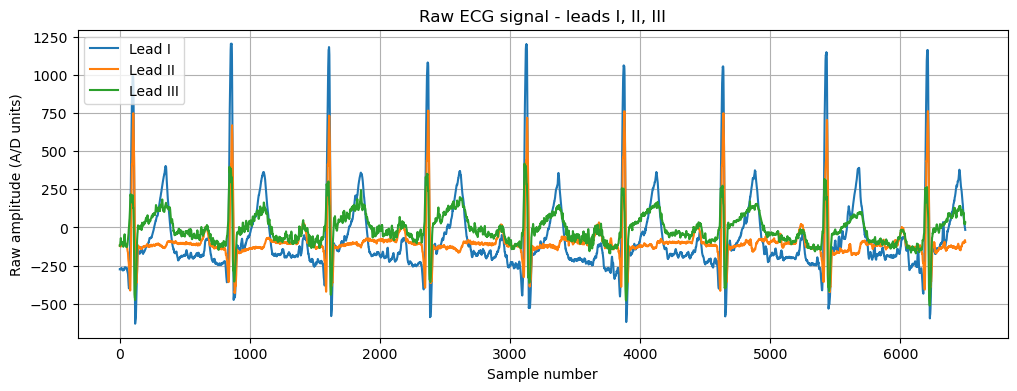

In [5]:
# CELL 4: plot the raw ECG data (all three leads)
plt.figure(figsize=(12, 4))
plt.plot(ecg_raw)
plt.xlabel("Sample number")
plt.ylabel("Raw amplitude (A/D units)")
plt.title("Raw ECG signal - leads I, II, III")
plt.legend(["Lead I", "Lead II", "Lead III"])
plt.grid()
plt.show()

### Check of the raw plot
- 3 lines are drawn, one per lead, as expected from the 3 columns.
- The x axis runs from 0 to ~6500, matching the number of samples.
- The signal is periodic, with ~7 sharp peaks (QRS complexes) visible.
- Amplitudes range roughly from -600 to +1200 A/D units. These are
  arbitrary units, so they cannot yet be compared to physiological values.

In [6]:
# CELL 6: rescale the raw data to standard units
# equipment specification: A/D gain = 1024, sampling frequency = 1000 Hz
AD_GAIN = 1024
SAMPLING_FREQUENCY_HZ = 1000

ecg_mV = ecg_raw / AD_GAIN
print(ecg_mV.min(), ecg_mV.max())
n_samples = ecg_raw.shape[0]
time_s = np.arange(n_samples) / SAMPLING_FREQUENCY_HZ

-0.6171875 1.177734375


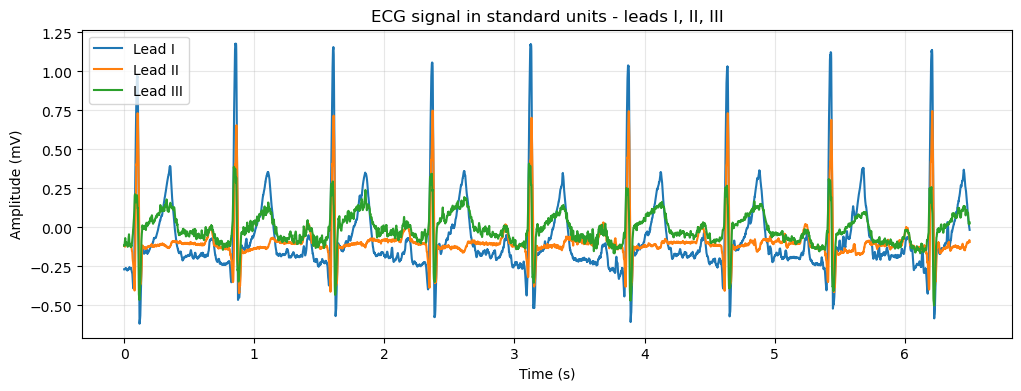

In [7]:
# CELL 7: plot the rescaled ECG data
plt.figure(figsize=(12, 4))
plt.plot(time_s, ecg_mV)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("ECG signal in standard units - leads I, II, III")
plt.legend(["Lead I", "Lead II", "Lead III"])
plt.grid(True, alpha=0.3)
plt.show()



In [ ]:
# CELL: numerical evidence for the check cell
LEAD_NAMES = ["Lead I", "Lead II", "Lead III"]

#Check: number of timeseries and of samples
n_samples, n_leads = ecg_raw.shape
duration_s = n_samples / SAMPLING_FREQUENCY_HZ
print(f"shape          : {ecg_raw.shape}  ->  {n_leads} leads, {n_samples} samples")
print(f"duration       : {duration_s} s")
print(f"time axis      : {time_s[0]:.3f} s to {time_s[-1]:.3f} s")

#Check: value range
print(f"\noverall range  : {ecg_mV.min():.2f} to {ecg_mV.max():.2f} mV")
for i, name in enumerate(LEAD_NAMES):
    lead = ecg_mV[:, i]
    print(f"  {name:9s} min {lead.min():6.2f}  max {lead.max():6.2f}  baseline {np.median(lead):6.2f}  mV")

# Check: the conversion formula
ecg_as_written = ecg_raw * AD_GAIN / 1000    
print(f"\nformula as written : {ecg_as_written.min():8.1f} to {ecg_as_written.max():8.1f} mV")
print(f"dividing by gain   : {ecg_mV.min():8.2f} to {ecg_mV.max():8.2f} mV")
print(f"ratio between them : {AD_GAIN**2 / 1000:.0f}x")

# Check: heart rate 
# crude QRS detection: points far above baseline, keeping one per complex
lead_I = ecg_mV[:, 0]
baseline_I = np.median(lead_I)
threshold = baseline_I + 0.5 * (lead_I.max() - baseline_I)

above = lead_I > threshold
qrs_starts = np.where(above[1:] & ~above[:-1])[0] + 1   
n_qrs = len(qrs_starts)
print(f"\nQRS complexes detected : {n_qrs}")
print(f"heart rate             : {n_qrs / duration_s * 60:.0f} bpm")
print(f"QRS times (s)          : {np.round(time_s[qrs_starts], 3)}")

# Check: do the leads agree in time?
print("\nQRS times per lead (s):")
for i, name in enumerate(LEAD_NAMES):
    lead = ecg_mV[:, i]
    base = np.median(lead)
    dev = np.abs(lead - base)                  
    thr = base_thr = 0.5 * dev.max()
    hit = dev > thr
    starts = np.where(hit[1:] & ~hit[:-1])[0] + 1
    print(f"  {name:9s} {np.round(time_s[starts], 3)}")

shape          : (6500, 3)  ->  3 leads, 6500 samples
duration       : 6.5 s
time axis      : 0.000 s to 6.499 s

overall range  : -0.62 to 1.18 mV
  Lead I    min  -0.62  max   1.18  baseline  -0.15  mV
  Lead II   min  -0.42  max   0.75  baseline  -0.11  mV
  Lead III  min  -0.50  max   0.41  baseline  -0.02  mV

formula as written :   -647.2 to   1234.9 mV
dividing by gain   :    -0.62 to     1.18 mV
ratio between them : 1049x

QRS complexes detected : 9
heart rate             : 83 bpm
QRS times (s)          : [0.089 0.843 1.593 2.354 3.111 3.862 4.623 5.416 6.195]

QRS times per lead (s):
  Lead I    [0.089 0.843 1.593 2.354 3.111 3.862 4.623 5.416 6.195]
  Lead II   [0.091 0.851 1.598 2.358 3.118 3.866 4.627 5.423 6.199]
  Lead III  [0.111 0.839 0.871 1.588 1.597 1.617 1.853 2.348 2.379 3.107 3.138 3.858
 3.866 3.886 4.618 4.627 4.647 5.413 5.442 6.19  6.201 6.218]


### Check of the rescaled ECG plot

**Are the number of timeseries correct?**
Yes. Three lines are plotted, one per column of `ecg_mV`, matching the three
leads (I, II, III) listed in the equipment specification.

**Are the number of samples correct?**
Yes. `ecg_raw.shape` is (6500, 3), and at a sampling frequency of 1000 Hz this
gives 6500 / 1000 = 6.5 s of recording. The x axis of the plot runs from 0 to
6.5 s, as expected.

**Are the values consistent with the expected range of an ECG signal?**
Yes, after correcting the conversion (see below). The observed range is
-0.62  to 1.18  mV, with the R wave peaking at about 1.18 mV in lead I.

**Note on the conversion formula.**
Applying the formula as written in the instructions (raw x 1024 uV) gives a
range of about -630 to +1240 mV, roughly 1000 times larger than any
physiological ECG. Dividing by 1024 instead gives values in the expected
range. The gain of 1024 is therefore best read as A/D units per millivolt
(about 0.98 uV per unit), not microvolts per unit.

**Additional check 1: is the heart rate plausible?**
9 QRS complexes are visible over the 6.5 s window, which gives
9 / 6.5 x 60 ~ 83 bpm. This falls in the normal sinus range of
60-100 bpm. This check is useful because it validates the *time* axis
independently of the amplitude axis: an error in the assumed sampling
frequency would produce an implausible heart rate even if the mV values
looked correct.

**Additional check 2: do the three leads agree with each other?**
The QRS complexes occur at the same time instants in all three leads, as they
must, since the leads are simultaneous recordings of the same heartbeats from
different electrode pairs. Their amplitudes and polarities differ, which is
also expected. A time offset between leads would indicate a loading or
indexing error (for example, columns read in the wrong order or shifted).